# Physics-Informed Neural Network (PINN) for 1D Wave Equation

We’ll solve the **1D Wave Equation** using a **PINN (Physics-Informed Neural Network)**

---

## Problem setup

We solve the **1D wave equation**:

$$
u_{tt}(x,t) = c^2\,u_{xx}(x,t), \quad (x,t) \in (0,1) \times (0,1)
$$

**Boundary and Initial Conditions:**

$$
u(0,t) = u(1,t) = 0, \quad u(x,0) = \sin(\pi x), \quad u_t(x,0) = 0
$$

**Exact Solution (for \( c = 1 \)):**

$$
u(x,t) = \sin(\pi x)\cos(\pi t)
$$


Epoch 00000 | Total: 1.16e+00 | PDE: 9.96e-03 | IC: 8.84e-01 | BC: 2.64e-01
Epoch 00500 | Total: 4.17e-02 | PDE: 1.79e-03 | IC: 1.35e-02 | BC: 2.64e-02
Epoch 01000 | Total: 1.49e-02 | PDE: 5.29e-04 | IC: 6.45e-03 | BC: 7.93e-03
Epoch 01500 | Total: 1.91e-03 | PDE: 9.06e-04 | IC: 5.99e-04 | BC: 4.08e-04
Epoch 02000 | Total: 1.61e-03 | PDE: 6.15e-04 | IC: 7.41e-04 | BC: 2.53e-04
Epoch 02500 | Total: 4.79e-04 | PDE: 2.02e-04 | IC: 2.34e-04 | BC: 4.32e-05
Epoch 03000 | Total: 3.21e-04 | PDE: 1.64e-04 | IC: 1.20e-04 | BC: 3.73e-05
Epoch 03500 | Total: 2.81e-04 | PDE: 1.11e-04 | IC: 1.32e-04 | BC: 3.76e-05
Epoch 04000 | Total: 8.35e-04 | PDE: 4.22e-04 | IC: 2.60e-04 | BC: 1.53e-04
Epoch 04500 | Total: 3.36e-04 | PDE: 1.17e-04 | IC: 1.33e-04 | BC: 8.57e-05
Epoch 05000 | Total: 1.65e-03 | PDE: 4.40e-04 | IC: 5.89e-04 | BC: 6.25e-04
Epoch 05500 | Total: 3.95e-04 | PDE: 7.88e-05 | IC: 2.46e-04 | BC: 7.09e-05


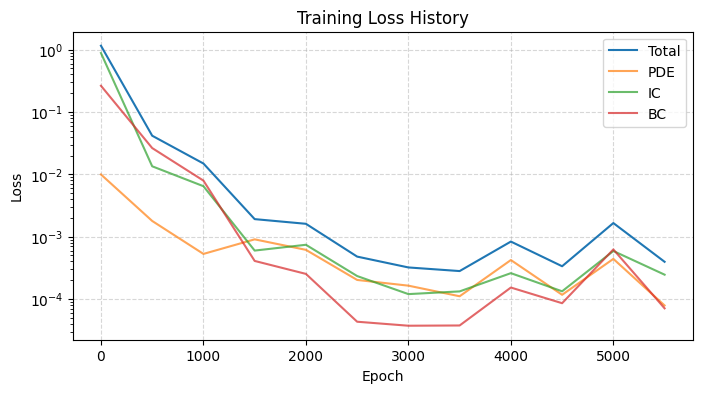


Relative L2 Error: 9.21e-03


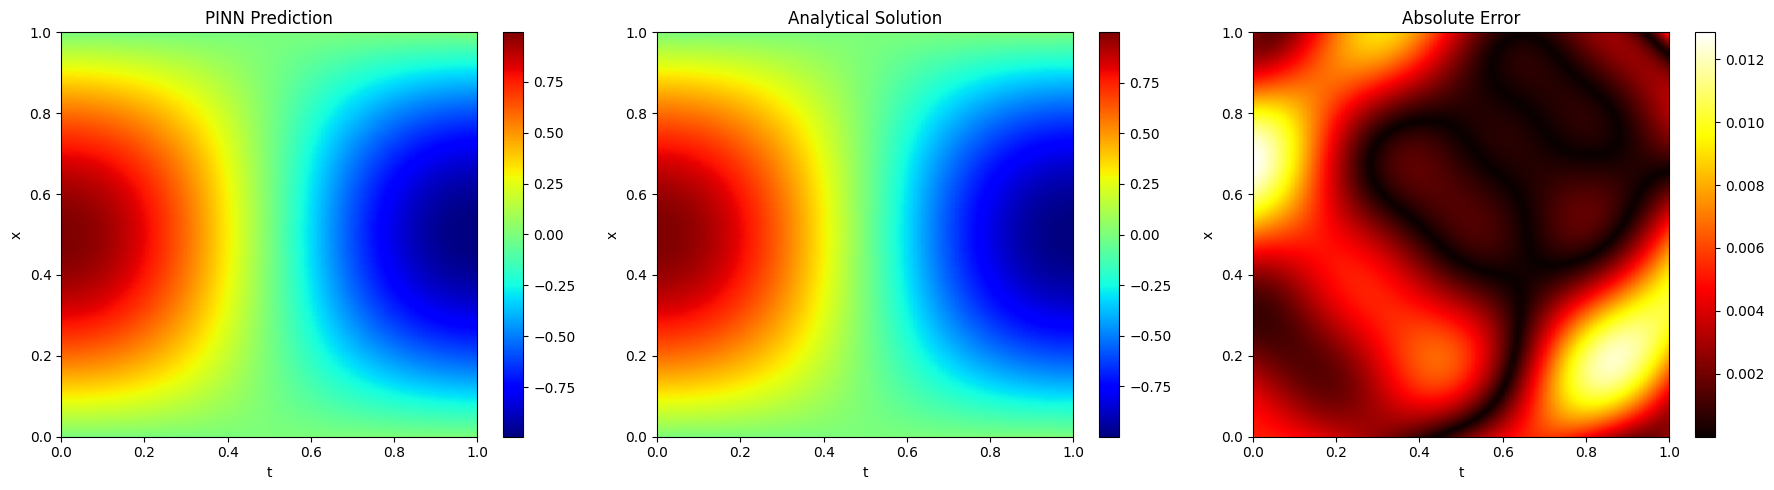

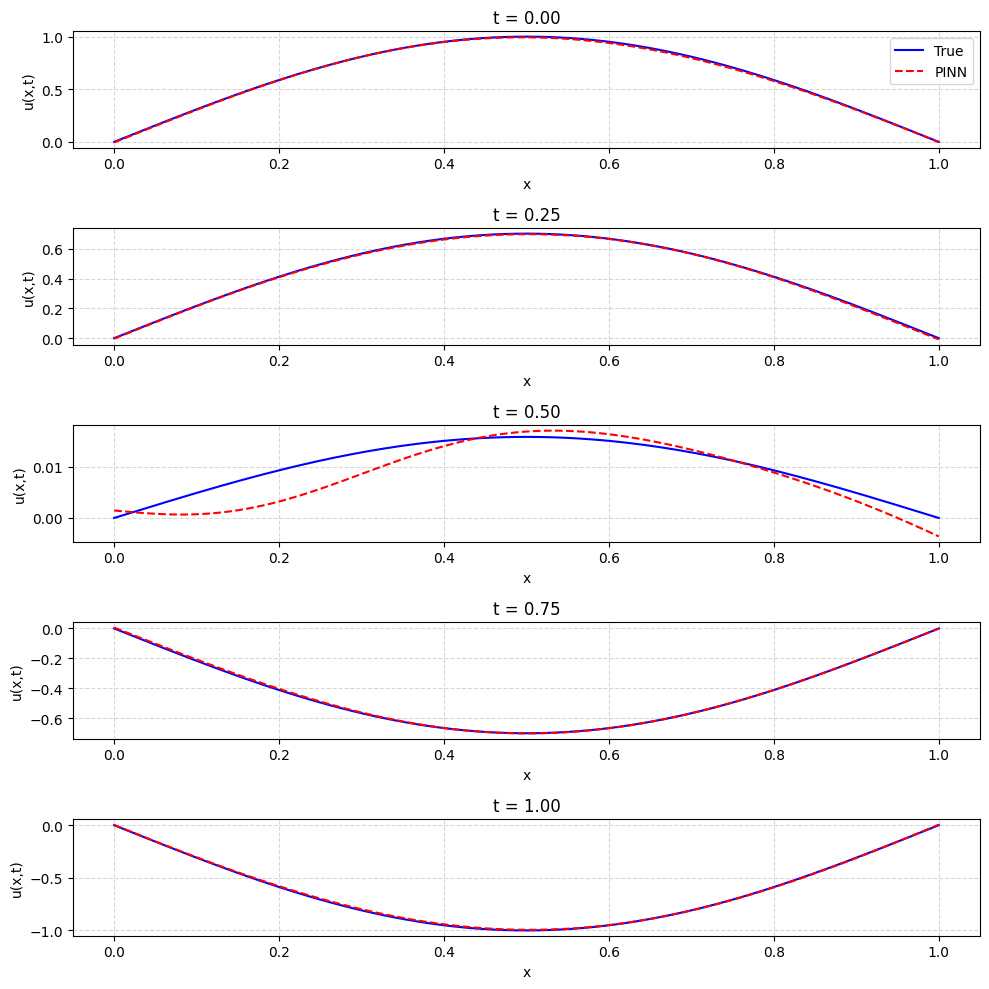

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------
# 1. Setup
# ---------------------------------------------------------------
tf.keras.backend.set_floatx('float32')
PI = tf.constant(np.pi, dtype=tf.float32)
c = tf.constant(1.0, dtype=tf.float32)

# ---------------------------------------------------------------
# 2. Neural Network Definition
# ---------------------------------------------------------------
def make_model(n_layers=5, n_neurons=64):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,), dtype=tf.float32))
    for _ in range(n_layers - 1):
        model.add(tf.keras.layers.Dense(n_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal',
                                        dtype=tf.float32))
    model.add(tf.keras.layers.Dense(1, dtype=tf.float32))
    return model

# ---------------------------------------------------------------
# 3. Physics-Informed Loss Function
# ---------------------------------------------------------------
@tf.function
def compute_losses(model, x_pde, t_pde, x_ic, t_ic, t_bc):
    xt_pde = tf.concat([x_pde, t_pde], axis=1)
    xt_ic  = tf.concat([x_ic, t_ic], axis=1)
    xt_bc0 = tf.concat([tf.zeros_like(t_bc), t_bc], axis=1)
    xt_bc1 = tf.concat([tf.ones_like(t_bc),  t_bc], axis=1)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch([xt_pde, xt_ic])

        # --- PDE residual ---
        u_pde = model(xt_pde)
        grads = tape.gradient(u_pde, xt_pde)
        u_x, u_t = grads[:, 0:1], grads[:, 1:2]
        u_xx = tape.gradient(u_x, xt_pde)[:, 0:1]
        u_tt = tape.gradient(u_t, xt_pde)[:, 1:2]
        f = u_tt - (c ** 2) * u_xx
        loss_pde = tf.reduce_mean(tf.square(f))

        # --- Initial conditions ---
        u_ic_pred = model(xt_ic)
        u_ic_true = tf.sin(PI * x_ic)
        du_dt_ic = tape.gradient(u_ic_pred, xt_ic)[:, 1:2]
        loss_ic = tf.reduce_mean(tf.square(u_ic_pred - u_ic_true)) + \
                  tf.reduce_mean(tf.square(du_dt_ic))

        # --- Boundary conditions ---
        u_bc0 = model(xt_bc0)
        u_bc1 = model(xt_bc1)
        loss_bc = tf.reduce_mean(tf.square(u_bc0)) + tf.reduce_mean(tf.square(u_bc1))

    del tape
    total_loss = loss_pde + loss_ic + loss_bc
    return total_loss, loss_pde, loss_ic, loss_bc

# ---------------------------------------------------------------
# 4. Data Sampling
# ---------------------------------------------------------------
def sample_points(N_pde=10000, N_ic=200, N_bc=200):
    x_pde = tf.random.uniform((N_pde, 1), 0, 1, dtype=tf.float32)
    t_pde = tf.random.uniform((N_pde, 1), 0, 1, dtype=tf.float32)
    x_ic = tf.linspace(0.0, 1.0, N_ic)[:, None]
    t_ic = tf.zeros_like(x_ic, dtype=tf.float32)
    t_bc = tf.random.uniform((N_bc, 1), 0, 1, dtype=tf.float32)
    return x_pde, t_pde, x_ic, t_ic, t_bc

# ---------------------------------------------------------------
# 5. Training with Adam Optimizer
# ---------------------------------------------------------------
model = make_model()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
EPOCHS = 6000
history = []

for ep in range(EPOCHS):
    x_pde, t_pde, x_ic, t_ic, t_bc = sample_points()
    with tf.GradientTape() as tape:
        total_loss, loss_pde, loss_ic, loss_bc = compute_losses(model, x_pde, t_pde, x_ic, t_ic, t_bc)
    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if ep % 500 == 0:
        history.append([ep, total_loss.numpy(), loss_pde.numpy(), loss_ic.numpy(), loss_bc.numpy()])
        print(f"Epoch {ep:05d} | Total: {total_loss.numpy():.2e} | PDE: {loss_pde.numpy():.2e} | IC: {loss_ic.numpy():.2e} | BC: {loss_bc.numpy():.2e}")


# ---------------------------------------------------------------
# 6. Loss History Plot
# ---------------------------------------------------------------
H = np.array(history)
plt.figure(figsize=(8, 4))
plt.plot(H[:, 0], H[:, 1], label='Total')
plt.plot(H[:, 0], H[:, 2], label='PDE', alpha=0.7)
plt.plot(H[:, 0], H[:, 3], label='IC', alpha=0.7)
plt.plot(H[:, 0], H[:, 4], label='BC', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.show()

# ---------------------------------------------------------------
# 7. Evaluation and Visualization
# ---------------------------------------------------------------
nx, nt = 200, 100
xv = np.linspace(0, 1, nx)
tv = np.linspace(0, 1, nt)
X, T = np.meshgrid(xv, tv)
xt = tf.convert_to_tensor(np.hstack([X.flatten()[:, None], T.flatten()[:, None]]), dtype=tf.float32)

U_pred = model(xt).numpy().reshape(nt, nx)
U_true = np.sin(np.pi * X) * np.cos(np.pi * T)
Err = np.abs(U_true - U_pred)

# --- Relative L2 Error ---
rel_L2 = np.linalg.norm(U_true - U_pred) / np.linalg.norm(U_true)
print(f"\nRelative L2 Error: {rel_L2:.2e}")

# ---------------------------------------------------------------
# 8. Heatmaps
# ---------------------------------------------------------------
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(1, 3, figure=fig)
for i, (Z, title, cmap) in enumerate([
    (U_pred, "PINN Prediction", "jet"),
    (U_true, "Analytical Solution", "jet"),
    (Err, "Absolute Error", "hot")
]):
    ax = fig.add_subplot(gs[0, i])
    pcm = ax.pcolormesh(T, X, Z, shading='gouraud', cmap=cmap)
    fig.colorbar(pcm, ax=ax)
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_title(title)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 9. 1D Snapshots
# ---------------------------------------------------------------
snap_times = [0.0, 0.25, 0.5, 0.75, 1.0]
plt.figure(figsize=(10, 10))
for i, t_val in enumerate(snap_times, 1):
    idx = np.argmin(np.abs(tv - t_val))
    plt.subplot(len(snap_times), 1, i)
    plt.plot(xv, U_true[idx, :], 'b-', label='True')
    plt.plot(xv, U_pred[idx, :], 'r--', label='PINN')
    plt.title(f"t = {t_val:.2f}")
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.grid(True, ls='--', alpha=0.5)
    if i == 1:
        plt.legend()
plt.tight_layout()
plt.show()
